# Tree Protection Orders (TPOs) in Dundee

This project explores the patterns, distribution, and characteristics of Tree Preservation Orders (TPOs) across Dundee, using a cleaned dataset of 155 records derived from Council TPO documentation. The analysis focuses on when TPOs were issued, how old they are today, and where they are most heavily concentrated.

# Contents
**[Imports and constants](#imports_and_constants)**

**[Helper Functions](#helper_f)**

**[Main Functions: Data Import, Cleaning, and Visualisations](#main_f)**  
   Loading the dataset, cleaning missing values, extracting year/age fields, and assigning areas.

**[Visualisations](#visualisations)**  
   - **TPOs per Year** - Line chart showing long‑term trends and peak TPOs in 2007.  
   - **TPO Age Distribution** - Histogram of TPO protection ages.
   - **TPOs by Area** - Bar chart comparing counts across Dundee areas.

**[Summary](#summary)** 
   Short summaries into temporal patterns, TPO age distribution, and area counts.

## <a id=imports_and_constants></a>Imports and Constants

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from datetime import datetime
import requests, time

from IPython.display import display, Markdown
from pathlib import Path
import logging

In [2]:
logging.basicConfig(level=logging.INFO)

### Constants

In [3]:
# get notebook's root dir
ROOT = Path().resolve()

# get the data folder relative to the root directory
DATA_DIR = ROOT / 'data'

# data file
CSV_FILE = DATA_DIR / 'TPODundeeData.csv'
OUTPUT_FILE = DATA_DIR / 'cleanedTPODataDundee.csv'

AREA_MATCHES = DATA_DIR / 'area_match.csv'

# newline
NL = '\n'

DATE_COL = ['TPOREFNO']
COLS_STANDARD = ['ADDRESS1', 'ADDRESS2', 'ADDRESS3']

YEAR_REGEX = r'\d{2,4}$'
VALID_TPO = r'^\d{2}\/\d{2,4}$'

COLOUR = '#252b73'

## <a id=helper_f></a>Helper Functions

In [4]:
def _extract_year(tpo, year_regex):
    match =re.search(year_regex, str(tpo))
    if not match:
        log.debug(f"No year found in TPOREFNO '{tpo}'... defaulting to 2000.")
        return 2000 # fallback year
    
    year = int(match.group())
    if year < 100:
        year += 1900 if year > 30 else 2000
    return year

In [5]:
def _standardise_addresses(value):
    """Map missing ADDRESS values to 'Dundee'."""
    if pd.isna(value):
        return 'Dundee'

    return value.strip().title()

In [6]:
def _full_address(row):
    parts = [
        str(row.get('ADDRESS1', '')),
        str(row.get('ADDRESS2', '')),
        str(row.get('ADDRESS3', '')),
    ]
    # join non-empty, non-nan parts
    full = ', '.join(p.strip() for p in parts if p.strip() and p.lower() != 'nan')
    # strip Dundee variants (case-insensitive) since Nominatim gets it from context
    full = re.sub(r',?\s*dundee\b', '', full, flags=re.IGNORECASE).strip().strip(',')
    return full

## <a id=main_f></a>Main Functions

### Load Data

In [7]:
def load_data(input_path: str, tpo_regex: str) -> pd.DataFrame:
    """Reads the CSV and checks for missing or malformed entries.
       Inspects the dataset for duplicate entries or inconsistent formatting."""
    logging.info(f"Loading data from: {input_path}")
    if not Path.exists(input_path):
        logging.error(f"Input file not found: {input_path.name}")
        raise FileNotFoundError(input_path)
    df = pd.read_csv(input_path)
    logging.info(f"{input_path.name} loaded successfully: {df.shape[0]} rows by {df.shape[1]} cols.")

    # log missing values, only log columns where missing values are present
    logging.warning(f"Missing values are present in columns:{NL}{df.isna().sum()[df.isna().sum() > 0]}")

    # log duplicate rows
    duplicate_rows = df[df.duplicated(keep=False)]
    if not duplicate_rows.empty:
        logging.info(f"Duplicate rows found:{NL}{duplicate_rows}")
    else:
        logging.info("No duplicate rows found.")

    # check and log valid tpo
    valid_tpo = df['TPOREFNO'].str.match(VALID_TPO, na=False)
    bad_tpo   = df.loc[~valid_tpo, 'TPOREFNO']
    if bad_tpo.empty:
        logging.info("All TPOREFNO values are well-formed (NN/YY).")
    else:
        logging.warning(f"Malformed TPOREFNO values:{NL}{bad_tpo.to_string()}.")
        
    return df

### Clean Data

In [8]:
def clean_data(df: pd.DataFrame, cols_to_standardise: list, date_col: str, year_regex: str) -> pd.DataFrame:
    """Standardises categorical columns. 
       Converts numeric or date-like fields to correct types.
       Adds 'Year' col.
       Adds 'TPOAge' col.
       Handles missing values.
       """
    for col in cols_to_standardise:
        df[col] = df[col].apply(_standardise_addresses)
    logging.info(f"Missing values have been filled and captitalisation has been applied to columns: {cols_to_standardise}.")
        
    # add year col      
    df['Year'] = df['TPOREFNO'].apply(lambda v: _extract_year(v, year_regex)).astype(int)
    logging.info("'Year' column has been added.")
    # add tpo age col
    df['TPOAge'] = datetime.now().year - df['Year'].astype(int)
    logging.info("'TPOAge' column has been added.")
    # combine all address cols into one for nominatim lookup
    df['FullAddress'] = df.apply(_full_address, axis=1)
    logging.info("'FullAddress' column has been added.")
    # add area column
    # check if cache exists to avoid re-calling api
    if AREA_MATCHES.exists():
        df['Area'] = pd.read_csv(AREA_MATCHES)['Area']
        logging.info(f"Matched areas from {AREA_MATCHES.name}.")
    else:
        df['Area'] = df['FullAddress'].apply(geocode_address)
        df[['TPOREFNO', 'FullAddress', 'Area']].to_csv(AREA_MATCHES, index=False)
        logging.info("Matched areas using Nominatim API lookup.")

    # drop na left
    df = df.dropna()
    
    return df

### Area Lookup

In [ ]:
# def geocode_address(address: str) -> dict:
#     """Uses full address col to call nominatim api to try find an area match."""
#     url = 'https://nominatim.openstreetmap.org/search'
#     params = {
#         'q': f"{address}, Dundee, Scotland",
#         'format': 'json',
#         'addressdetails': 1,
#         'limit': 1
#     }
#     headers = {'User-Agent': 'TPODundeeAnalysis/1.0'}
#     r = requests.get(url, params=params, headers=headers)
#     time.sleep(1)
#     results = r.json()
#     if results:
#         addr = results[0].get('address', {})
#         # suburb, then neighbourhood, then quarter
#         return addr.get('suburb') or addr.get('neighbourhood') or addr.get('quarter')
#     return None

### Save Data

In [9]:
def save_data(df: pd.DataFrame, output_filename: str):
    """Save cleaned dataset."""
    if Path(output_filename).exists():
       logging.error(f"Output filename '{output_filename.name}' already exists.")
    
    df.to_csv(output_filename, index=False)
    logging.info(f"Cleaned and transformed file saved as '{output_filename.name}'.")

### Figures

In [10]:
def plot_tpos_per_year(df: pd.DataFrame) -> plt.Figure:
    tpo_counts = df.groupby('Year').size()
    peak = tpo_counts.idxmax() # most tpos

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.plot(tpo_counts.index, tpo_counts.values,
            color=COLOUR, linewidth=2, marker='o',
            markersize=6, markerfacecolor='white', markeredgewidth=2, label='TPOs per year')

    # highlight the peak year
    ax.annotate(f"Peak: {peak} ({tpo_counts[peak]} TPOs)",
                xy=(peak, tpo_counts[peak]),
                xytext=(peak + 1, tpo_counts[peak] + 0.3),
                fontsize=9, color='#000000',
                arrowprops=dict(arrowstyle='-', color='#000000')),

    ax.set_title('TPOs Issued per Year', fontsize=14)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Number of TPOs', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    fig.tight_layout()
    #plt.savefig('tpo_per_year.png', bbox_inches='tight')
    return fig

In [11]:
def plot_tpos_by_area(df: pd.DataFrame) -> plt.Figure:
    counts = df['Area'].value_counts().dropna().sort_values()

    fig, ax = plt.subplots(figsize=(12,6))

    bars = ax.barh(counts.index, counts.values,
                   color=COLOUR, edgecolor='white', zorder=3)

    # value labels on each bar
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.1, bar.get_y() + bar.get_height() / 2,
                str(int(w)), va='center', fontsize=9)

    ax.set_title('TPO Count by Area', fontsize=14)
    ax.set_xlabel('Number of TPOs', fontsize=11)
    ax.set_ylabel('Area', fontsize=11)
    ax.grid(True, axis = 'x', which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    fig.tight_layout()
    #plt.savefig('tpo_by_area.png', bbox_inches='tight')
    return fig

In [12]:
def plot_tpo_age_distribution(df: pd.DataFrame) -> plt.Figure:
    ages = df['TPOAge'].dropna()

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.hist(ages, bins=20, color=COLOUR, edgecolor='white', linewidth=0.8, zorder=2)
    ax.axvline(ages.mean(),   color='#E63946', linestyle='--', linewidth=1.8, label=f'Mean   {ages.mean():.1f} yrs')
    ax.axvline(ages.median(), color='#F18F01', linestyle=':',  linewidth=1.8, label=f'Median {ages.median():.1f} yrs')

    ax.set_title('Distribution of TPO Protection Ages', fontsize=14)
    ax.set_xlabel('Years of Protection (TPOAge)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    fig.tight_layout()
    #plt.savefig('tpo_age_distribution.png', bbox_inches='tight')
    return fig

In [13]:
def generate_visualisations(df):
    with plt.ioff():
        # pre-create figures
        logging.info(f"Creating visual: TPOs per year...")
        tpo_per_year = plot_tpos_per_year(df)
        logging.info(f"Creating visual: TPO age distribution...")
        tpo_age = plot_tpo_age_distribution(df)
        logging.info(f"Creating visual: TPO counts by area...")
        tpo_by_area = plot_tpos_by_area(df)

    # TPOs per year
    display(Markdown("## TPOs per Year"))
    display(Markdown("A line chart visualising the annual TPO issuance, revealing a clear surge between 2003–2012, with a peak in **2007 (14 TPOs)**."
    ))
    display(tpo_per_year)
    plt.close(tpo_per_year) # close

    # TPO age distribution
    display(Markdown("## TPO Age Distribution"))
    display(Markdown("Histogram showing a strong central cluster around **15–25 years**."))
    display(tpo_age)
    plt.close(tpo_age) # close

    # TPOs by area
    display(Markdown("## TPOs by Area"))
    display(Markdown("Bar chart showing that **Broughty Ferry** contains over eight times more TPOs than the next-highest area."))
    display(tpo_by_area)
    plt.close(tpo_by_area) # close

## <a id=visualisations></a>Visualisations

In [14]:
def main():
    df = load_data(CSV_FILE, VALID_TPO)
    df = clean_data(df, COLS_STANDARD, DATE_COL, YEAR_REGEX)
    save_data(df, OUTPUT_FILE)
    generate_visualisations(df)

INFO:root:TPODundeeData.csv loaded successfully: 155 rows by 6 cols.
ADDRESS1    2
ADDRESS2    1
ADDRESS3    8
dtype: int64
INFO:root:No duplicate rows found.
80    01.
INFO:root:Missing values have been filled and captitalisation has been applied to columns: ['ADDRESS1', 'ADDRESS2', 'ADDRESS3'].
INFO:root:'Year' column has been added.
INFO:root:'TPOAge' column has been added.
INFO:root:'FullAddress' column has been added.
INFO:root:Matched areas from area_match.csv.
ERROR:root:Output filename 'cleanedTPODataDundee.csv' already exists.
INFO:root:Cleaned and transformed file saved as 'cleanedTPODataDundee.csv'.
INFO:root:Creating visual: TPOs per year...
INFO:root:Creating visual: TPO age distribution...
INFO:root:Creating visual: TPO counts by area...


## TPOs per Year

A line chart visualising the annual TPO issuance, revealing a clear surge between 2003–2012, with a peak in **2007 (14 TPOs)**.

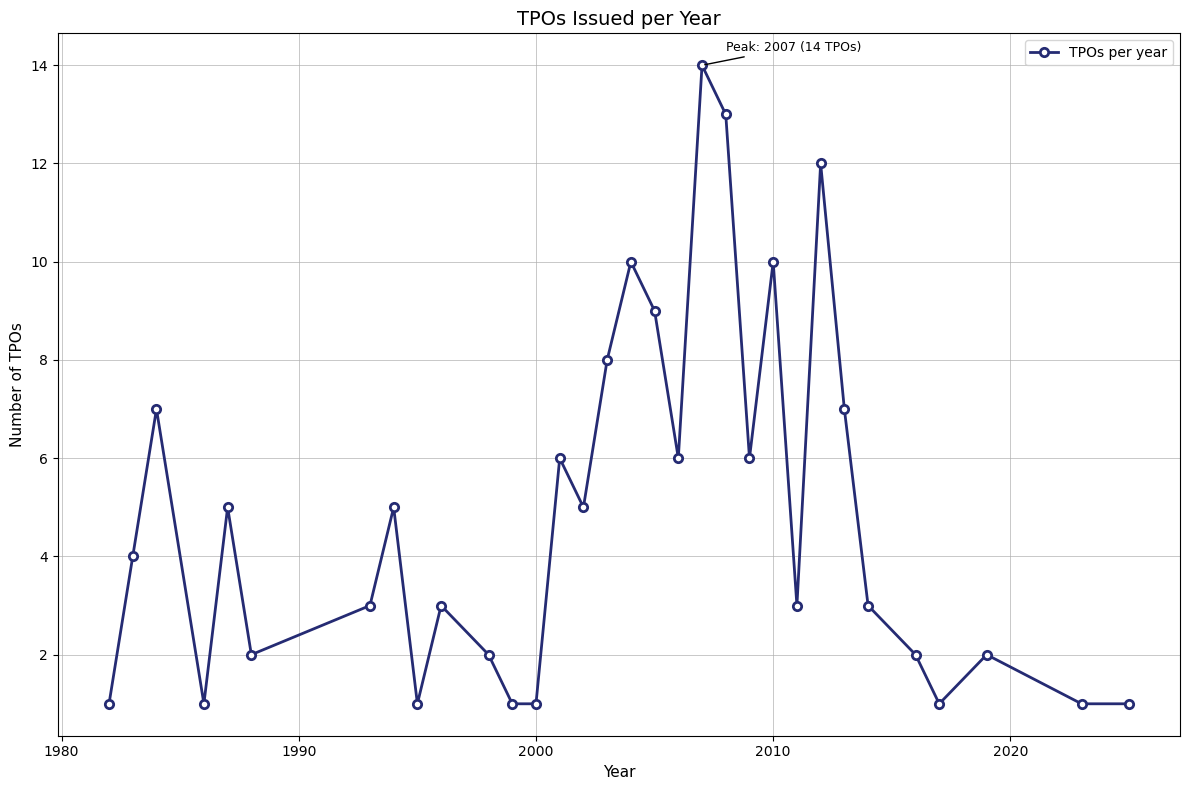

## TPO Age Distribution

Histogram showing a strong central cluster around **15–25 years**.

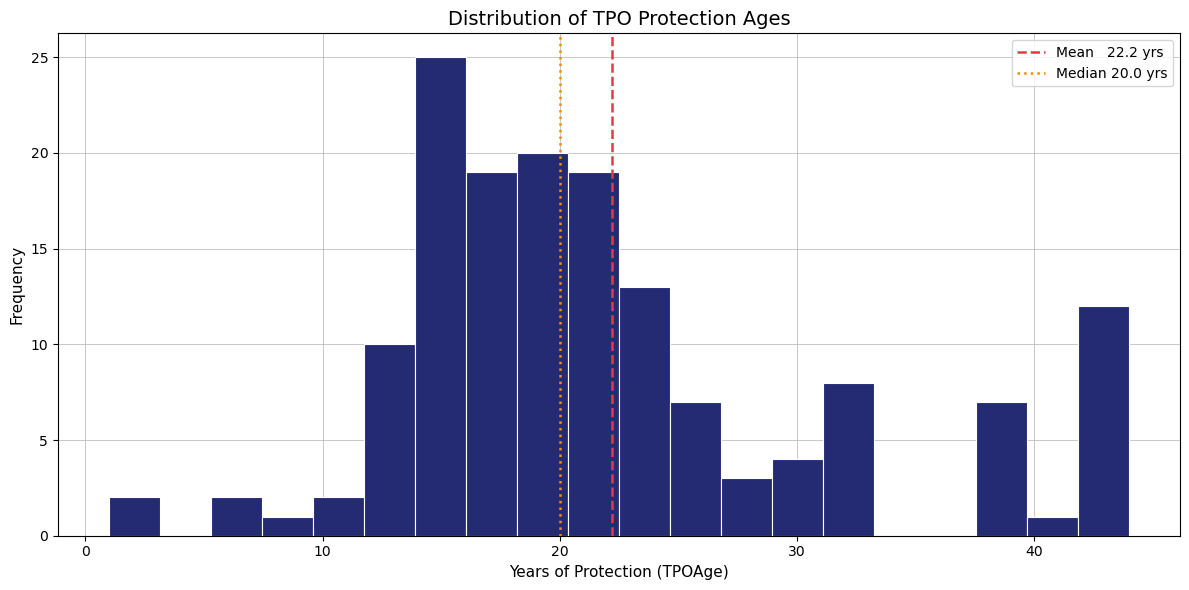

## TPOs by Area

Bar chart showing that **Broughty Ferry** contains over eight times more TPOs than the next-highest area.

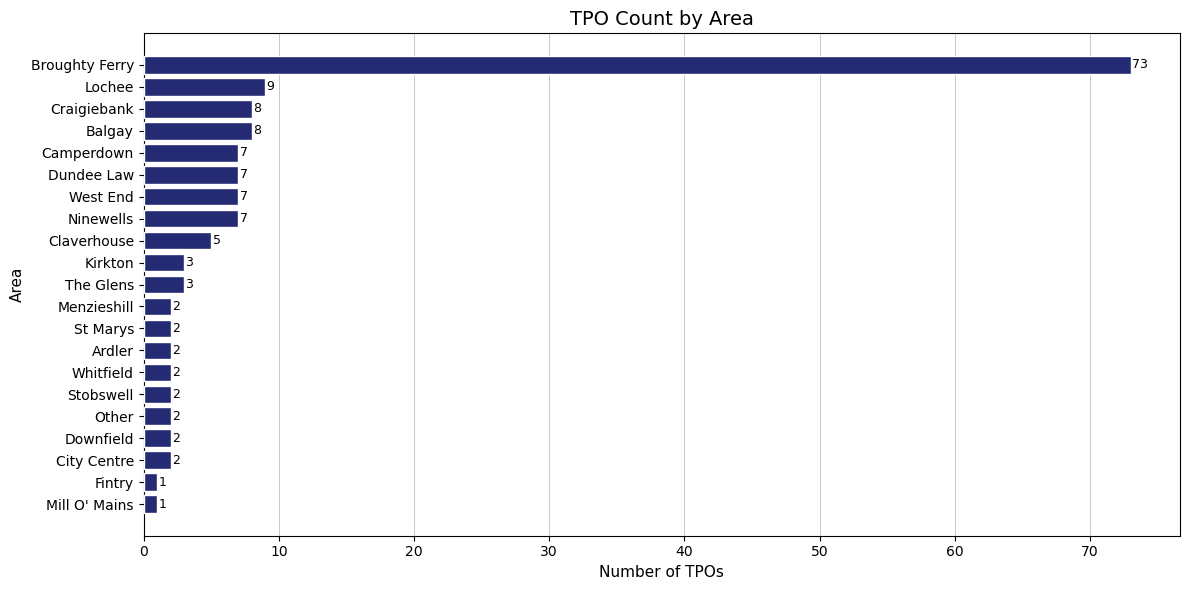

In [15]:
main()

## <a id=summary></a>Summary

### TPOs per Year
A peak number of 14 TPOs were issued in 2007. 
TPO activity steadily increased from the early 2000s, forming a clear cluster of issued orders between 2003-2012 before dropping off sharply from 2012. Earlier small peaks appear in the 1980s, although these pale in comparison to the 2000s surge.


### Years of Protection
Years of protection range from 1 to 44 years, showing a spread from recently issued to longstanding protections. The median age is 20 years with a mean of around 22.2 years, and a majority of TPOs fall between the age of 15 and 25 years, which indicates that most TPOs are mature but not historic.

  
### TPOs by Area
Broughty Ferry accounts for over 8 times more TPOs than any other area. According to the *Broughty Ferry Conservation Area Appraisal*, the landscape of Broughty Ferry ranges from open coastal frontage along Douglas Terrace to the tree-lined streets of Dundee Road, with mature private gardens playing a significant role in shaping the townscape and contributing to the Conservation Area's historic identity.
This concentration of mature vegetation - both private and public, helps explain the high number of TPOs. Trees here are central to the area's setting, amenity, and heritage value.

**Data Quality Note:** Area names were derived using address-based lookup via the Nominatim API. Some ambiguous addresses required manual assignment, so a small degree of inaccuracy is likely. 

## References
Dundee City Council (no date) *Broughty Ferry Conservation Area Appraisal*. Available at: https://www.dundeecity.gov.uk/sites/default/files/publications/Broughty%20Conservation%20Area%20Appraisal%20web%20version.pdf.